# Creation of proteins and methods

The aim of this notebook is to extract all the necessary information of each protein, like an identity card (ID), to simplify afterward the manipulation of the protein objects. Then methods will be added to interact with those latter objects.

## I/ Importation

In [1]:
# Not needed
#import sys
#sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/src")
#sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/.pixi")
#sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/Data")

import re
import numpy as np
import gudhi as gd
from gudhi import DelaunayCechComplex
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from pathlib import Path
from tp_pims.config import TP_PATH
from tp_pims.vizualize_filtration import extract_ca_atom_pos

## Creation of a protein class

Creation of an object representing proteins which stores their topological data, making the manipulation of proteins easier, acting like a identity card for each protein

The methods will allow the latter ID to be completed with the needed infos

In [2]:
# Class representing proteins and their topological data (TDA)
class Protein:

    def __init__(self, code, sequence=None, data_file=None):
        # Basic infos
        self.code = code
        self.sequence = sequence
        self.length = len(sequence) if sequence else None

        # Management of the path of the files
        # !!! May be an issue, please check your own path
        if data_file is None:
            self.data_file = TP_PATH / "Data"
        else:
            self.data_file = Path(data_file)

        self.file_name = f"AF-{code}-F1-model_v6.pdb"
        self.path = self.data_file / self.file_name
        self.file_exist = self.path.exists()

        # Futur attributes, that will be stored in the protein, to be easier to access
        self._structure = None
        self._pos_ca = None
        self._simplex_tree = None
        self._diagram_raw = None
        self._diagram_np = None

    # Return the 3D structure of the protein, as in the notebook of Jules Fauchon (cf. TP1)
    def get_structure(self):
        if self._structure is None:
            if not self.file_exist:
                raise FileNotFoundError(f"File not found for {self.code}: {self.path}")
            # Mode PERMISSIVE=1 pour éviter de crasher sur de légères anomalies du file PDB
            parser = PDBParser(PERMISSIVE=1)
            self._structure = parser.get_structure(id=self.code, file=self.path.open("r"))
        return self._structure

    # Get the coordinates of alpha carbon (CA) (can be adaptated to get other kind of atoms)
    def get_ca_coordinates(self):
        if self._pos_ca is None:
            structure = self.get_structure()
            # Extraction completed thanks to the already existing function (cf. TP1)
            self._pos_ca = extract_ca_atom_pos(list(structure.get_residues()))
        return f"CA coordinates have been successfully extracted, here's the coordinates of the first CA : {self._pos_ca[0]}"

    # Creation of a simplicial complex (Delaunay-Cech) and calculation of the persistence
    def get_simplex_tree(self):
        if self._simplex_tree is None:
            if self._pos_ca is None:
                raise Warning(f"CA coordinates have not been extracted yet, please run get_ca_coordinates first")
            pos_ca = self._pos_ca
            cech_cs = DelaunayCechComplex(points=pos_ca)
            self._simplex_tree = cech_cs.create_simplex_tree()
            self._simplex_tree.compute_persistence()
        return self._simplex_tree

    # Return the barcode in 1D (containing values needed for persistance and barcode diagram)
    def get_raw_barcode(self):
        if self._diagram_raw is None:
            simplex_tree = self.get_simplex_tree()
            self._diagram_raw = simplex_tree.persistence_intervals_in_dimension(1)
        return f"Values have been successfully calculated"

    # Return a numpy dataframe later used in the Wasserstein distance calculation
    def get_diagram_numpy(self):
        if self._diagram_np is None:
            diagram = self.get_raw_barcode()
            diagram_filtered = []
            for d in diagram:
                if d[1] != float('inf') and not np.isinf(d[0]) and not np.isinf(d[1]):
                    diagram_filtered.append([d[0], d[1]])

            if diagram_filtered:
                self._diagram_np = np.array(diagram_filtered)
            else:
                self._diagram_np = np.array([]).reshape(0, 2)
        return f"Values have been successfully calculated"

    # Return the standard persistence diagram
    def plot_diagram(self):
        if self._diagram_raw is None:
            raise Warning(f"Values seems to be missing, please run get_raw_barcode first")
        diagram = self._diagram_raw
        if len(diagram) > 0:
            fig, ax = plt.subplots(figsize=(8, 6))
            gd.plot_persistence_diagram(diagram, axes=ax)
            ax.set_title(f"Persistence diagram of {self.code}")
            plt.show()
        else:
            print(f"The diagram is empty for {self.code}")

    # Return the standard barcode diagram
    def plot_barcode(self):
        if self._diagram_raw is None:
            raise Warning(f"Values seems to be missing, please run get_raw_barcode first")
        diagram = self._diagram_raw
        if len(diagram) > 0:
            fig, ax = plt.subplots(figsize=(10, 5))
            gd.plot_persistence_barcode(diagram, axes=ax)
            ax.set_title(f"Persistence barcode of {self.code}")
            plt.show()
        else:
            print(f"The barcode is empty for  {self.code}")

    # Calculates the Wasserstein distance between two proteins (not finished yet, please consider it as a draft)
    def get_wasserstein_distance(self, other_protein, order=2):
        from gudhi.wasserstein import wasserstein_distance

        if self._diagram_np is None:
            raise Warning(f"Values seems to be missing, please run get_diagram_numpy first")
        diag1 = self._diagram_np()
        diag2 = other_protein._diagram_np()

        if len(diag1) == 0 or len(diag2) == 0:
            print(f"Impossible de comparer : diagramme vide.")
            return None

        return wasserstein_distance(diag1, diag2, order=order)

    def __repr__(self):
        return f"<Protein code = {self.code}, length = {self.longueur}, file = {self.file_existe}>"

## III/ Name extraction of the proteins

The next function, created by Louis, will allow the extraction of the protein sequences from the .fst file

In [3]:
# Codes (names) and sequences extraction from FASTA file 'globin_all_nn.fst'
def extraction_from_fasta(file):
    proteins = []
    current_code = ""
    current_sequence = []

    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_code and current_sequence:
                    proteins.append((current_code, ''.join(current_sequence)))
                    current_sequence = []
                # Code extraction (name of the protein contained in the file of the AA sequences)
                match = re.search(r'>[^|]+\|([A-Z0-9]+)', line)
                if match:
                    current_code = match.group(1)
                else:
                    match = re.search(r'>(\S+)', line)
                    current_code = match.group(1) if match else line[1:].split()[0]
            else:
                if current_code:
                    current_sequence.append(line)
        if current_code and current_sequence:
            proteins.append((current_code, ''.join(current_sequence)))

    return proteins

## IV/ Generation of all the proteins

The next function must be the first to be run since it will create the ID for each single protein, with basic infos such as the code (name), the AA sequence, and the length of this sequence

In [4]:
# Extract all sequences from the FASTA file, extract all the codes in PDB files, and finally instantiate and return all Protein object
def proteins_generation(data_file_path, fasta_file):

    file = Path(data_file_path)
    # Extraction of the sequences and conversion to a dictionary
    sequences_list = extraction_from_fasta(fasta_file)
    sequences_dict = dict(sequences_list) 
    
    proteins_list = []
    
    # Adaptation of the already existing function 'extraction_from_pdb'
    for pdb_file in file.glob("AF-*.pdb"):
        match = re.search(r'AF-([A-Z0-9]+)-', pdb_file.name)
        if match:
            code = match.group(1)
            sequence = sequences_dict.get(code)
            new_protein = Protein(code=code, sequence=sequence, data_file=file)

            new_protein.file_name = pdb_file.name
            new_protein.path = pdb_file
            new_protein.file_exist = True

            proteins_list.append(new_protein)
            
    return proteins_list

## V/ Infos checking

The next function allows the user to check which infos have been added to the ID (choosing which infos to check).
N.B. : The default setting will return every info

In [5]:
def get_infos(protein, length=True, sequence=True, file_name=True, structure=True, CA=True, simplex_tree=True,diagram_raw=True, diagram_np=True ):
    infos = [f"Protein : {protein.code}"]

    if length:
        infos.append(f"Length : {protein.length} AA" if protein.length else f"Length : None")
    if sequence:
        infos.append(f"Sequence : {protein.sequence}" if protein.sequence else f"Sequence : None")
    if file_name:
        infos.append(f"File : {protein.file_name}" if protein.file_name else f"File : None")
    if structure:
        infos.append(f"Structure : {protein._structure}" if protein._structure else f"Structure : None")
    if CA:
        infos.append(f"CA : Coordinates extracted" if protein._pos_ca is not None else f"CA : None")
    if simplex_tree:
        infos.append(f"Simplex tree : {protein._simplex_tree}" if protein._simplex_tree is not None else f"Simplex tree : Not created already")
    if diagram_raw:
        infos.append(f"Diagram raw : Created" if protein._diagram_raw is not None  else f"Diagram raw : Not created already")
    if diagram_np:
        infos.append(f"Diagram np : Created" if protein._diagram_np is not None else f"Diagram np : Not created already")

    return print("\n".join(infos))

## VI/ Utilisation

This part of the notebook will focus on the first uses of the methods and functions

### 1. Definition of the diverse paths

N.B. : Please change or ignore if possible the next cell, since it specific to the PyCharm environment

In [6]:
data_file_path = "/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/Data"
fasta_path = "Data/globin_all_nn.fst"

### 2. Creation of the proteins

Every protein contained in the Data file is extracted

In [7]:
extracted_proteins = proteins_generation(data_file_path, fasta_path)

### 3. Checking

Firstly, the number of proteins extracted

In [8]:
print(f"{len(extracted_proteins)} proteins have been extracted")

152 proteins have been extracted


The first two proteins will be used as an instance

In [9]:
prot_test1 = extracted_proteins[0]
prot_test2 = extracted_proteins[1]

The infos of the latter proteins are summarised below. Only the basic info appears, since the other ones haven't been processed

In [10]:
get_infos(prot_test1)
get_infos(prot_test2)

Protein : Q21618
Length : 349 AA
Sequence : MGNSSSSSSRINKKSESMEIRSKPNRSSVSGEFNKSKSMMDMSSKSSRMSTSTASNTSRQKSITSIKDKDRPKSSRESKNIEISRTKSMRKDSHPISAQGREIITQCFENPHSEFANKVVQRIFEKREDYQKYIMNLGKERSSIVNNRLKQLVEDIVAHIHDADFIESVSKQYGEEHVELKQYGFKPDFWVAVADAMTLEGVILDMANHQPADTVSAWSSLVTMIFSSVRDGYYSELRRHRMSSRRTLKHQSTVDSREENNEPSSSHSNGMATTAAGLLGQRDHSKSTPIQMTEEATPRNILANSRRDTLRSVSTYSTESTSHSGKRNGSDAPSTSSTTSSTTRRPIFE
File : AF-Q21618-F1-model_v6.pdb
Structure : None
CA : None
Simplex tree : Not created already
Diagram raw : Not created already
Diagram np : Not created already
Protein : P02001
Length : 141 AA
Sequence : MLTAEDKKLIQQAWEKAASHQEEFGAEALTRMFTTYPQTKTYFPHFDLSPGSDQVRGHGKKVLGALGNAVKNVDNLSQAMAELSNLHAYNLRVDPVNFKLLSQCIQVVLAVHMGKDYTPEVHAAFDKFLSAVSAVLAEKYR
File : AF-P02001-F1-model_v6.pdb
Structure : None
CA : None
Simplex tree : Not created already
Diagram raw : Not created already
Diagram np : Not created already


Only the first protein will get its ID updated

In [11]:
prot_test1.get_structure()
prot_test1.get_ca_coordinates()
prot_test1.get_simplex_tree()
prot_test1.get_raw_barcode()
#prot_test1.get_diagram_numpy() # A issue have occur and needs to be corrected

'Values have been successfully calculated'

As predicted, only the first one is updated

In [12]:
get_infos(prot_test1)
get_infos(prot_test2)

Protein : Q21618
Length : 349 AA
Sequence : MGNSSSSSSRINKKSESMEIRSKPNRSSVSGEFNKSKSMMDMSSKSSRMSTSTASNTSRQKSITSIKDKDRPKSSRESKNIEISRTKSMRKDSHPISAQGREIITQCFENPHSEFANKVVQRIFEKREDYQKYIMNLGKERSSIVNNRLKQLVEDIVAHIHDADFIESVSKQYGEEHVELKQYGFKPDFWVAVADAMTLEGVILDMANHQPADTVSAWSSLVTMIFSSVRDGYYSELRRHRMSSRRTLKHQSTVDSREENNEPSSSHSNGMATTAAGLLGQRDHSKSTPIQMTEEATPRNILANSRRDTLRSVSTYSTESTSHSGKRNGSDAPSTSSTTSSTTRRPIFE
File : AF-Q21618-F1-model_v6.pdb
Structure : <Structure id=Q21618>
CA : Coordinates extracted
Simplex tree : <gudhi.simplex_tree.SimplexTree object at 0x1222f9210>
Diagram raw : Created
Diagram np : Not created already
Protein : P02001
Length : 141 AA
Sequence : MLTAEDKKLIQQAWEKAASHQEEFGAEALTRMFTTYPQTKTYFPHFDLSPGSDQVRGHGKKVLGALGNAVKNVDNLSQAMAELSNLHAYNLRVDPVNFKLLSQCIQVVLAVHMGKDYTPEVHAAFDKFLSAVSAVLAEKYR
File : AF-P02001-F1-model_v6.pdb
Structure : None
CA : None
Simplex tree : Not created already
Diagram raw : Not created already
Diagram np : Not created already


The typical diagrams are then plotted

/Users/gaspard/PyCharmMiscProject/.venv/lib/python3.9/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


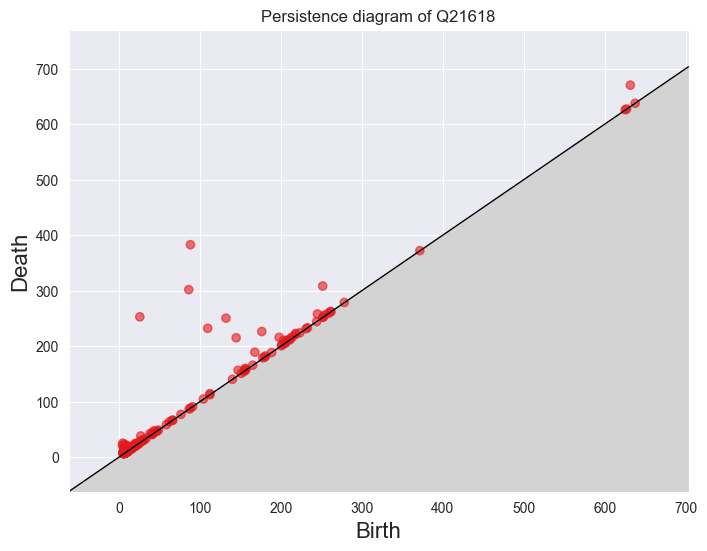

In [13]:
prot_test1.plot_diagram()

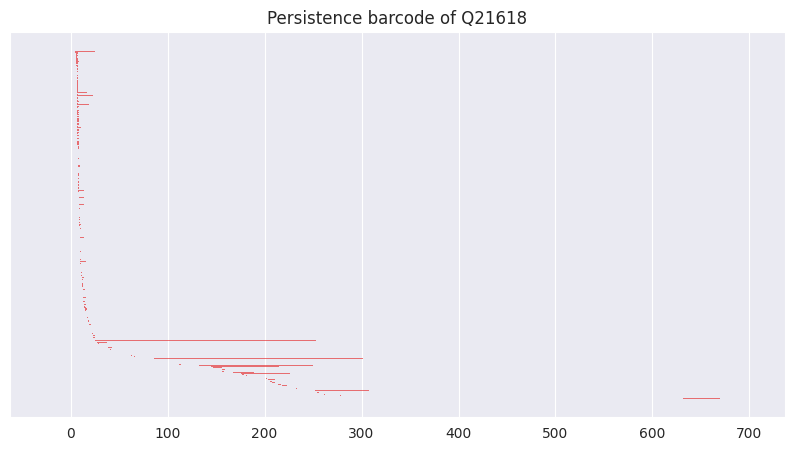

In [14]:
prot_test1.plot_barcode()

## VII/ For all proteins

The next cells will add the info for every proteins

In [15]:
for i in range(len(extracted_proteins)):
    extracted_proteins[i].get_structure()
    extracted_proteins[i].get_ca_coordinates()
    extracted_proteins[i].get_simplex_tree()
    extracted_proteins[i].get_raw_barcode()

In [16]:
get_infos(extracted_proteins[0]) # First protein
get_infos(extracted_proteins[1])
get_infos(extracted_proteins[151]) # There's 152 proteins, since the first one is n=0, the 152th is n=151

Protein : Q21618
Length : 349 AA
Sequence : MGNSSSSSSRINKKSESMEIRSKPNRSSVSGEFNKSKSMMDMSSKSSRMSTSTASNTSRQKSITSIKDKDRPKSSRESKNIEISRTKSMRKDSHPISAQGREIITQCFENPHSEFANKVVQRIFEKREDYQKYIMNLGKERSSIVNNRLKQLVEDIVAHIHDADFIESVSKQYGEEHVELKQYGFKPDFWVAVADAMTLEGVILDMANHQPADTVSAWSSLVTMIFSSVRDGYYSELRRHRMSSRRTLKHQSTVDSREENNEPSSSHSNGMATTAAGLLGQRDHSKSTPIQMTEEATPRNILANSRRDTLRSVSTYSTESTSHSGKRNGSDAPSTSSTTSSTTRRPIFE
File : AF-Q21618-F1-model_v6.pdb
Structure : <Structure id=Q21618>
CA : Coordinates extracted
Simplex tree : <gudhi.simplex_tree.SimplexTree object at 0x1222f9210>
Diagram raw : Created
Diagram np : Not created already
Protein : P02001
Length : 141 AA
Sequence : MLTAEDKKLIQQAWEKAASHQEEFGAEALTRMFTTYPQTKTYFPHFDLSPGSDQVRGHGKKVLGALGNAVKNVDNLSQAMAELSNLHAYNLRVDPVNFKLLSQCIQVVLAVHMGKDYTPEVHAAFDKFLSAVSAVLAEKYR
File : AF-P02001-F1-model_v6.pdb
Structure : <Structure id=P02001>
CA : Coordinates extracted
Simplex tree : <gudhi.simplex_tree.SimplexTree object at 0x10a700630>
Diagram raw : Created
Diagram np : No